# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [2]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


In [3]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

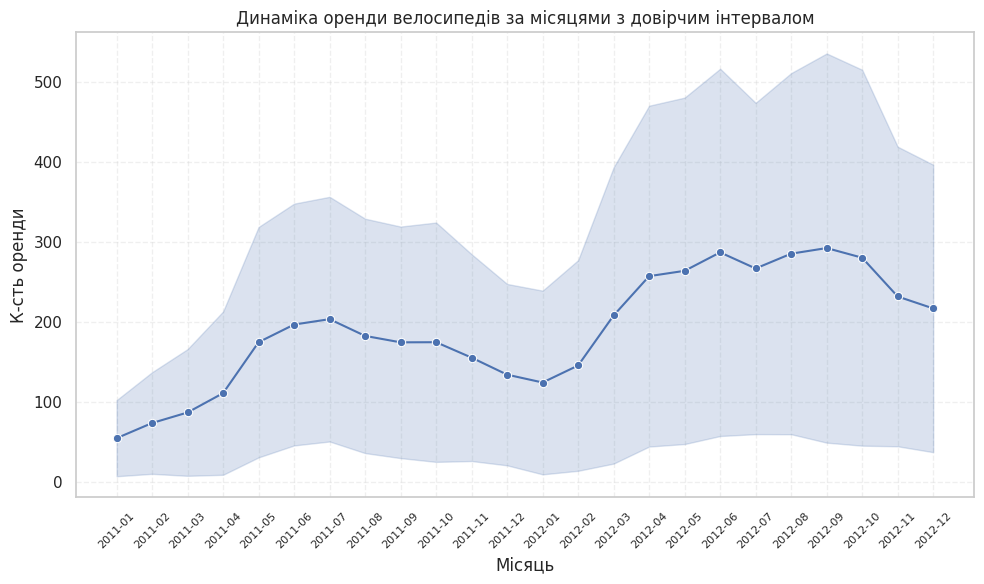

In [4]:
plt.figure(figsize=(10, 6))
sns.lineplot(df, x='month_year', y='count', errorbar='sd', marker='o')
plt.title('Динаміка оренди велосипедів за місяцями з довірчим інтервалом')
plt.xlabel('Місяць')
plt.ylabel('К-сть оренди')
plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.3);

В які місяці найбільша невизначеність в даних? - Квітень-вересень, тому що нйбільший розкид

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

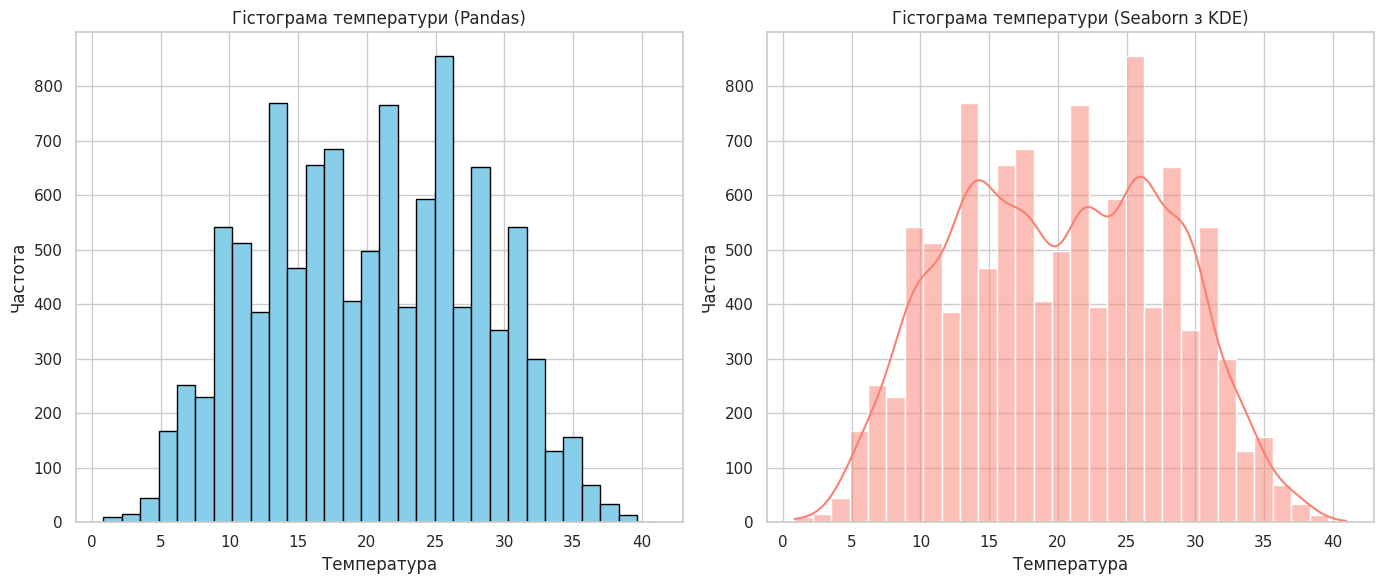

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bins = 30

# pd
df['temp'].plot(kind='hist', bins=bins, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Гістограма температури (Pandas)')
axes[0].set_xlabel('Температура')
axes[0].set_ylabel('Частота')

# sns
sns.histplot(df['temp'], bins=bins, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Гістограма температури (Seaborn з KDE)')
axes[1].set_xlabel('Температура')
axes[1].set_ylabel('Частота')

plt.tight_layout();

Sns не потрібно оформлювати краї. Загалом дуже схожі.

Kernel Density Estimate відображає згладжену оцінку ймовірнісного розподілу даних.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

/tmp/ipython-input-15851/2753790540.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='weather', y='count', ax=axes[1], palette='Blues')


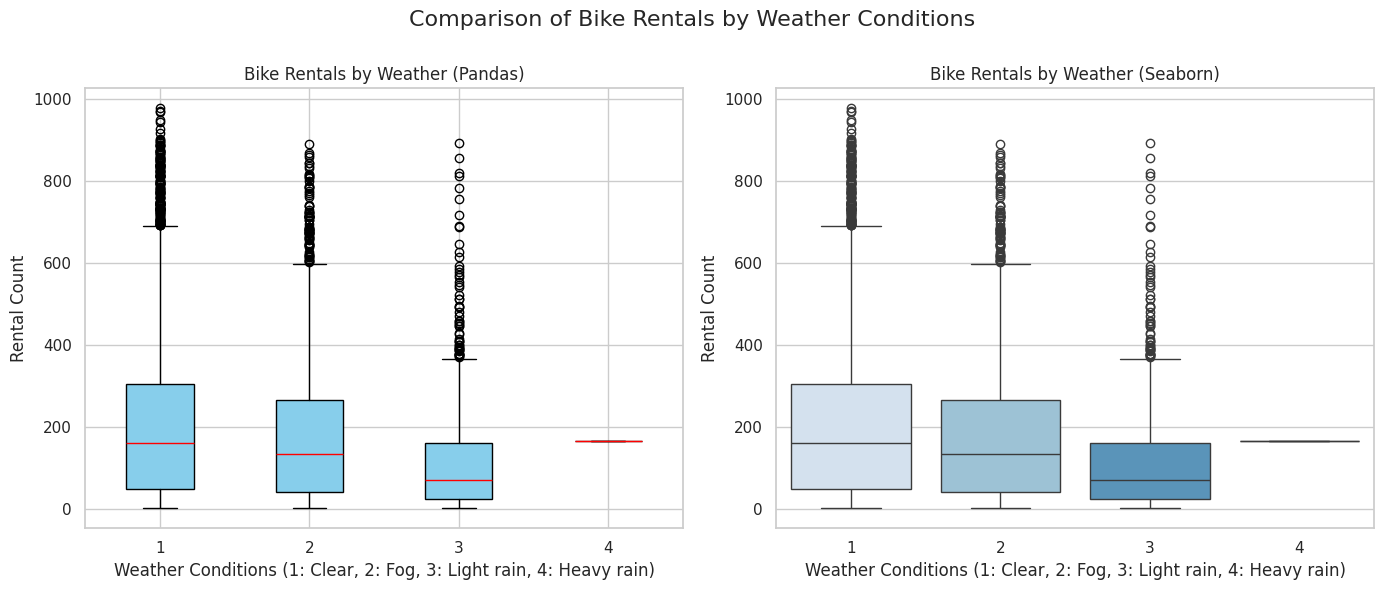

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pandas
df.boxplot(column='count', by='weather', ax=axes[0], patch_artist=True,
           medianprops={'color': 'red'}, boxprops=dict(facecolor='skyblue', color='black'),
           whiskerprops=dict(color='black'), capprops=dict(color='black'))


axes[0].set_title('Bike Rentals by Weather (Pandas)')
axes[0].set_xlabel('Weather Conditions (1: Clear, 2: Fog, 3: Light rain, 4: Heavy rain)')
axes[0].set_ylabel('Rental Count')

# Seaborn
sns.boxplot(data=df, x='weather', y='count', ax=axes[1], palette='Blues')


axes[1].set_title('Bike Rentals by Weather (Seaborn)')
axes[1].set_xlabel('Weather Conditions (1: Clear, 2: Fog, 3: Light rain, 4: Heavy rain)')
axes[1].set_ylabel('Rental Count')

# Display the plots
plt.tight_layout()
plt.suptitle('Comparison of Bike Rentals by Weather Conditions', fontsize=16)
plt.subplots_adjust(top=0.85);

Медіана - дефолтний колір. Ширина боків.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10886 entries, 2011-01-01 00:00:00 to 2012-12-19 23:00:00
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   season       10886 non-null  int64  
 1   holiday      10886 non-null  int64  
 2   workingday   10886 non-null  int64  
 3   weather      10886 non-null  int64  
 4   temp         10886 non-null  float64
 5   atemp        10886 non-null  float64
 6   humidity     10886 non-null  int64  
 7   windspeed    10886 non-null  float64
 8   casual       10886 non-null  int64  
 9   registered   10886 non-null  int64  
 10  count        10886 non-null  int64  
 11  date         10886 non-null  object 
 12  day          10886 non-null  int32  
 13  week         10886 non-null  UInt32 
 14  weekday_num  10886 non-null  int32  
 15  weekday      10886 non-null  object 
 16  year         10886 non-null  int32  
 17  month        10886 non-null  int32  
 18  hour       

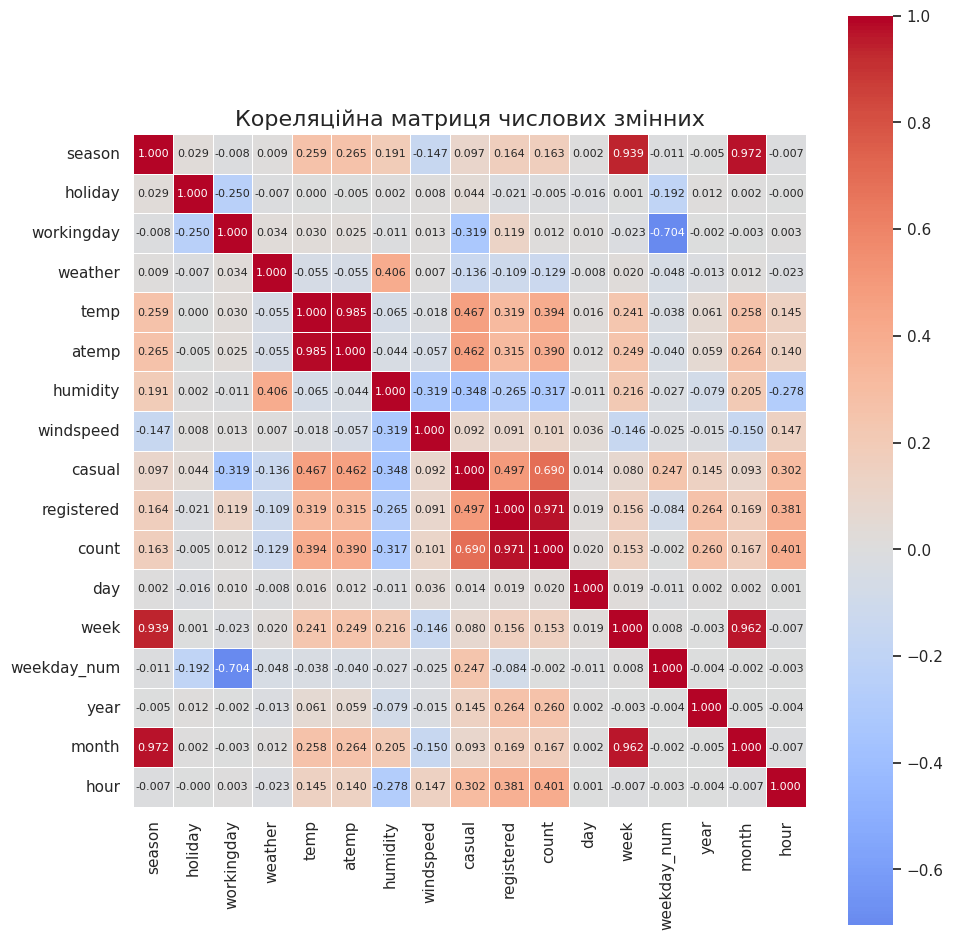

In [8]:
numeric_df = df.select_dtypes(include=['number', 'float64', 'int64'])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', cbar=True,
            linewidths=0.5, square=True, annot_kws={'size': 8})

plt.title('Кореляційна матриця числових змінних', fontsize=16)

plt.tight_layout();

Які змінні найсильніше корелюють з загальною кількістю оренди (count)? Зареєстровані користувачі, випадкові, час та температура

Яка кореляція між temp та atemp? Чому? Сильна позитивна кореляція. Відчутна температура змінюється в залежності від вітру, вологості та інших факторів, але основна залежність від реальної температури залишається, тому кореляція між ними часто висока.

Які змінні мають негативну кореляцію? Робочий день та день тижня. Вологість та випадкові користувачі.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


/tmp/ipython-input-15851/2414416164.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='season', y='count', data=df, palette='coolwarm')


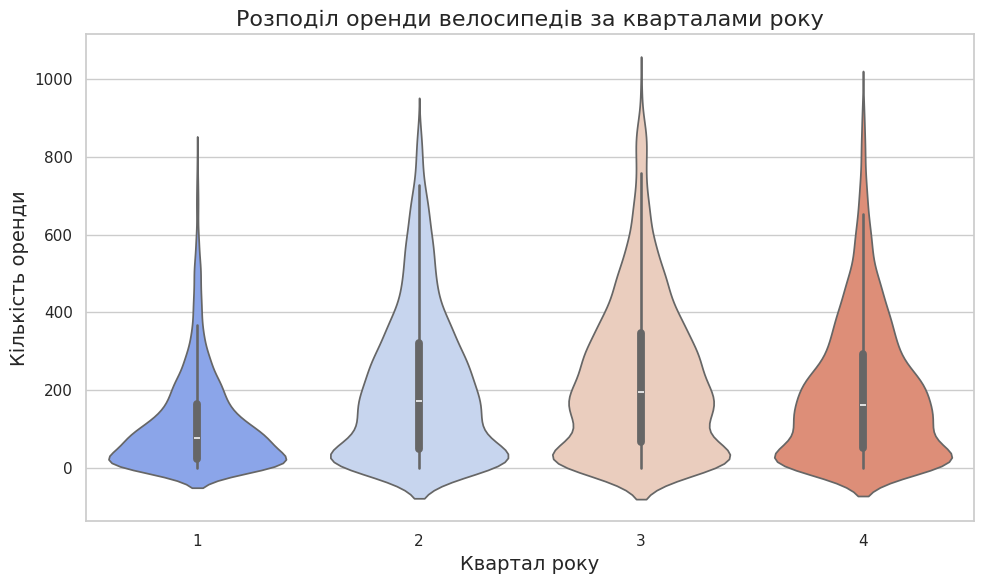

In [9]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='season', y='count', data=df, palette='coolwarm')

plt.title('Розподіл оренди велосипедів за кварталами року', fontsize=16)
plt.xlabel('Квартал року', fontsize=14)
plt.ylabel('Кількість оренди', fontsize=14)

plt.tight_layout();

Що показує "товщина" violin plot? - показує щільність розподілу значень для кожної категорії. Вона відображає, скільки даних зосереджено в певному діапазоні значень на осі Y

В якому кварталі найбільша варіабельність оренди? - 3

Яка перевага violin plot над звичайним box plot? Візуалізація щільності розподілу. Більш детальне уявлення про форму розподілу.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

<Figure size 1000x600 with 0 Axes>

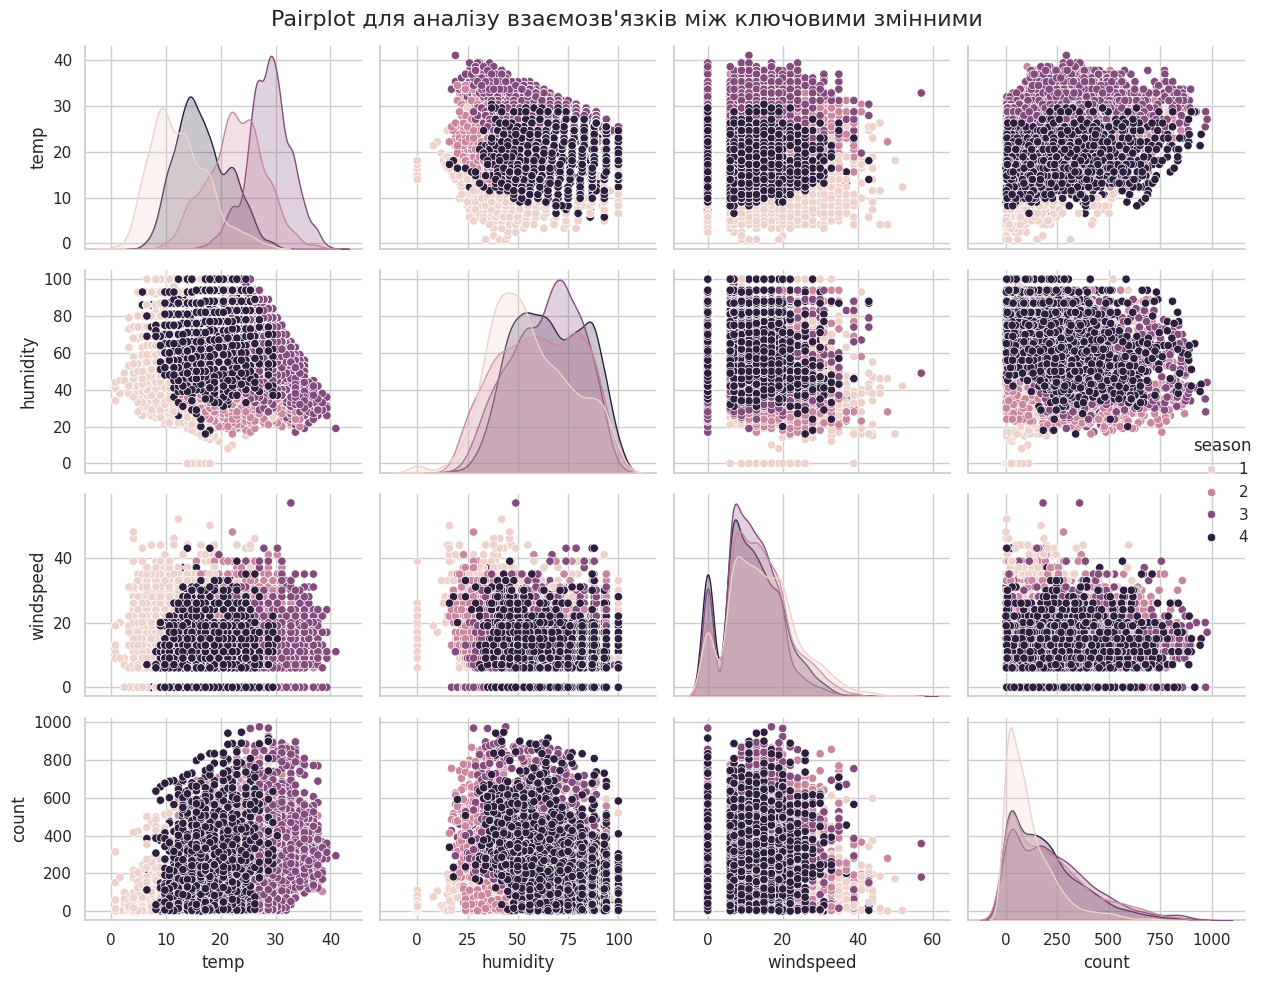

In [10]:
variables = ['temp', 'humidity', 'windspeed', 'count', 'season']

plt.figure(figsize=(10, 6))

sns.pairplot(df[variables], height=2.5, aspect=1.2, hue='season')

plt.suptitle('Pairplot для аналізу взаємозв\'язків між ключовими змінними', fontsize=16)

plt.tight_layout()

Між якими змінними спостерігається найсильніший лінійний зв'язок? Температура і кількість оренди

Яка характеристика найбільше відрізняється між кварталами? Швидкість вітру

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

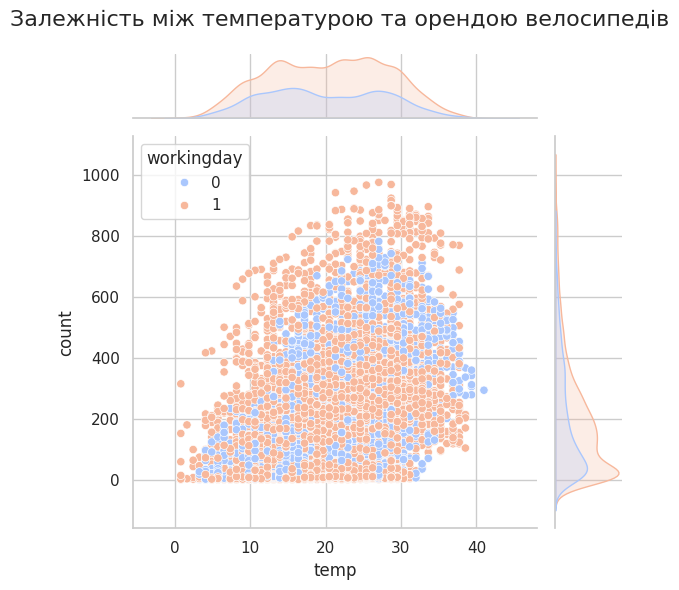

In [11]:
sns.jointplot(data=df, x='temp', y='count', hue='workingday', kind='scatter', palette='coolwarm')

plt.suptitle('Залежність між температурою та орендою велосипедів', fontsize=16)

plt.tight_layout()

Що показують графіки по краях? - Гістограми по краях показують лише одновимірний розподіл кожної змінної. Вони дозволяють побачити, як часто зустрічаються певні значення для кожної з змінних

Чи є різниця у поведінці користувачів у робочий і неробочий день? - У робочі дні більше замовлень